In [ ]:
# importing libraries

import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

In [25]:
os.chdir(r"D:\tech\ADVT_python\vehicle_damage_detection")   
print(os.getcwd())

D:\tech\ADVT_python\vehicle_damage_detection


In [26]:
# dataset paths

DATASET_PATH = "data"

TRAIN_IMAGES = os.path.join(DATASET_PATH, "train", "images")
TRAIN_LABELS = os.path.join(DATASET_PATH, "train", "labels")

VAL_IMAGES = os.path.join(DATASET_PATH, "val", "images")
VAL_LABELS = os.path.join(DATASET_PATH, "val", "labels")

TEST_IMAGES = os.path.join(DATASET_PATH, "test", "images")
TEST_LABELS = os.path.join(DATASET_PATH, "test", "labels")

In [ ]:
# dataset overview

print("DATASET OVERVIEW")

print(f"Training Images\t: {len(os.listdir(TRAIN_IMAGES))}")
print(f"Training Labels\t: {len(os.listdir(TRAIN_LABELS))}\n")

print(f"Validation Images: {len(os.listdir(VAL_IMAGES))}")
print(f"Validation Labels: {len(os.listdir(VAL_LABELS))}\n")

print(f"Testing Images\t: {len(os.listdir(TEST_IMAGES))}")
print(f"Testing Labels\t: {len(os.listdir(TEST_LABELS))}\n")

DATASET OVERVIEW
Training Images	: 2816
Training Labels	: 2816

Validation Images: 810
Validation Labels: 810

Testing Images	: 374
Testing Labels	: 374



In [ ]:
# dataset validation

# check missing labels
missing_labels = []

for image in os.listdir(TRAIN_IMAGES):
    label = image.replace(".jpg", ".txt")
    if not os.path.exists(os.path.join(TRAIN_LABELS, label)):
        missing_labels.append(image)

print("Missing Labels :", len(missing_labels))

# check missing images
missing_images = []

for label in os.listdir(TRAIN_LABELS):
    image = label.replace(".txt", ".jpg")
    if not os.path.exists(os.path.join(TRAIN_IMAGES, image)):
        missing_images.append(label)

print("Missing Images :", len(missing_images))

assert len(missing_images) == 0
assert len(missing_labels) == 0

print("Dataset Integrity Check Passed.")

Missing Labels : 0
Missing Images : 0
Dataset Integrity Check Passed.


In [30]:
CLASS_NAMES = {
    0: "Dent",
    1: "Scratch",
    2: "Crack",
    3: "Glass Shatter",
    4: "Lamp Broken",
    5: "Tire Flat"
}

In [ ]:
# visualize random dataset samples

def show_random_images(image_folder, n=6):
    image_list = random.sample(os.listdir(image_folder), n)
    plt.figure(figsize=(15, 10))
    for i, image_name in enumerate(image_list):
        image_path = os.path.join(image_folder, image_name)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title(image_name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

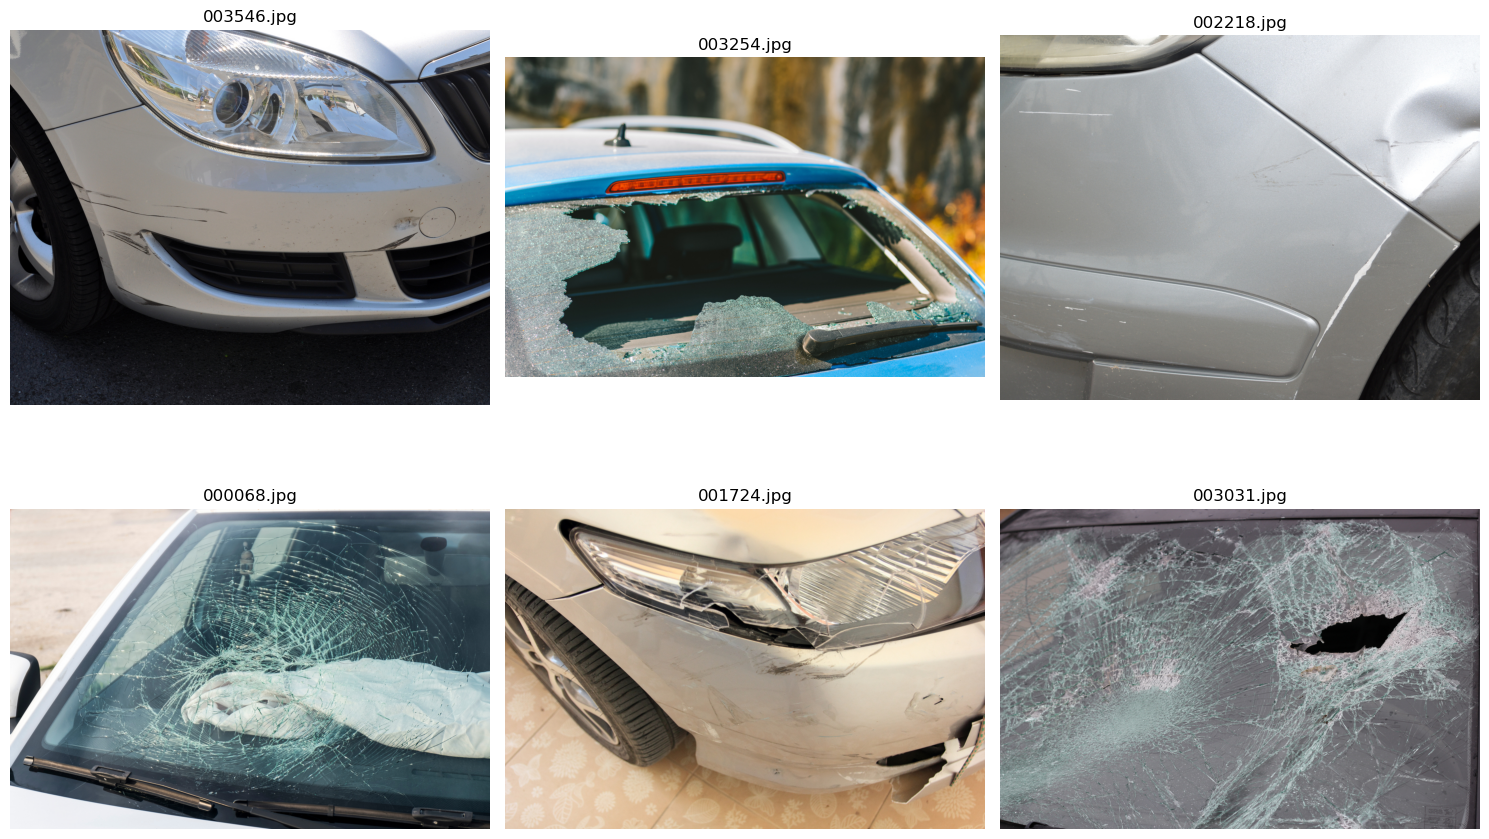

In [32]:
show_random_images(TRAIN_IMAGES)

In [ ]:
# visualizing bounding boxes

def draw_boxes(image_path, label_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    with open(label_path) as f:
        labels = f.readlines()
    for label in labels:
        cls, xc, yc, bw, bh = map(float, label.split())
        cls = int(cls)
        xc *= w
        yc *= h
        bw *= w
        bh *= h
        x1 = int(xc - bw / 2)
        y1 = int(yc - bh / 2)
        x2 = int(xc + bw / 2)
        y2 = int(yc + bh / 2)
        cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(
            image,
            CLASS_NAMES[cls],
            (x1, y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255,255,0),
            2
        )
    plt.figure(figsize=(10,7))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

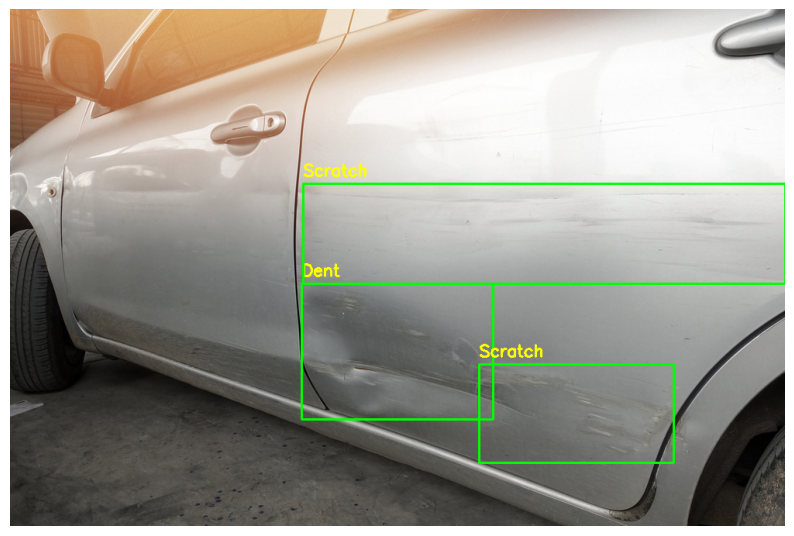

In [ ]:
sample = random.choice(os.listdir(TRAIN_IMAGES))

draw_boxes(
    os.path.join(TRAIN_IMAGES, sample),
    os.path.join(TRAIN_LABELS, sample.replace(".jpg", ".txt"))
)

In [ ]:
# damage class distribution

class_counter = Counter()

for label_file in os.listdir(TRAIN_LABELS):
    with open(os.path.join(TRAIN_LABELS, label_file)) as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counter[class_id] += 1

In [37]:
class_df = pd.DataFrame({
    "Damage Type": [CLASS_NAMES[i] for i in class_counter.keys()],
    "Count": list(class_counter.values())
})

class_df

,Damage Type,Count
0,Scratch,2560
1,Tire Flat,225
2,Crack,651
3,Dent,1806
4,Lamp Broken,494
5,Glass Shatter,475


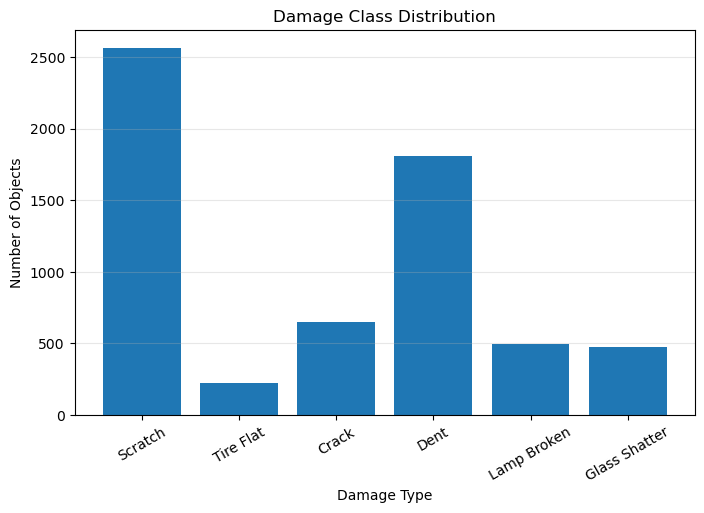

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(class_df["Damage Type"], class_df["Count"])
plt.title("Damage Class Distribution")
plt.xlabel("Damage Type")
plt.ylabel("Number of Objects")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
# image resolution analysis
image_sizes = []

for image_name in os.listdir(TRAIN_IMAGES):
    image_path = os.path.join(TRAIN_IMAGES, image_name)
    image = cv2.imread(image_path)
    height, width = image.shape[:2]
    image_sizes.append((width, height))

In [40]:
size_df = pd.DataFrame(
    image_sizes,
    columns=["Width", "Height"]
)

size_df.head()

,Width,Height
0,1000,750
1,1000,667
2,1000,667
3,1000,667
4,1000,667


In [41]:
print(size_df.describe())

             Width       Height
count  2816.000000  2816.000000
mean    978.997514   705.300781
std      77.448657    97.174243
min     562.000000   333.000000
25%    1000.000000   667.000000
50%    1000.000000   667.000000
75%    1000.000000   750.000000
max    1000.000000  1000.000000


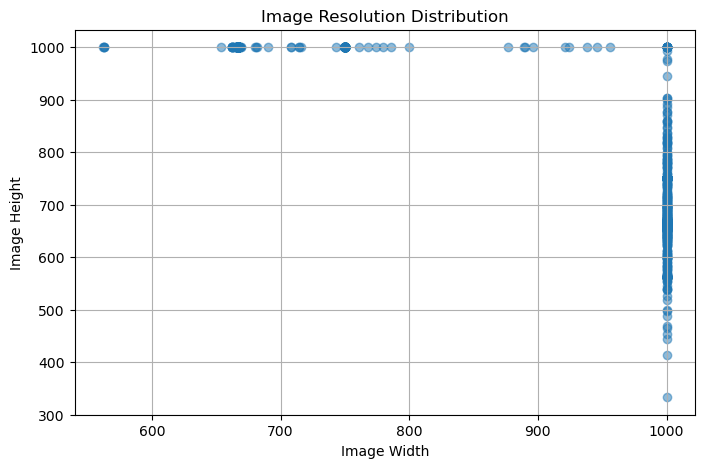

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(size_df["Width"], size_df["Height"], alpha=0.5)
plt.xlabel("Image Width")
plt.ylabel("Image Height")
plt.title("Image Resolution Distribution")
plt.grid(True)
plt.show()

In [ ]:
# objects / damages per image

objects_per_image = []

for label_file in os.listdir(TRAIN_LABELS):
    with open(os.path.join(TRAIN_LABELS, label_file)) as f:
        objects_per_image.append(len(f.readlines()))

In [44]:
objects_df = pd.DataFrame({
    "Objects": objects_per_image
})

objects_df.head()

,Objects
0,2
1,1
2,1
3,1
4,1


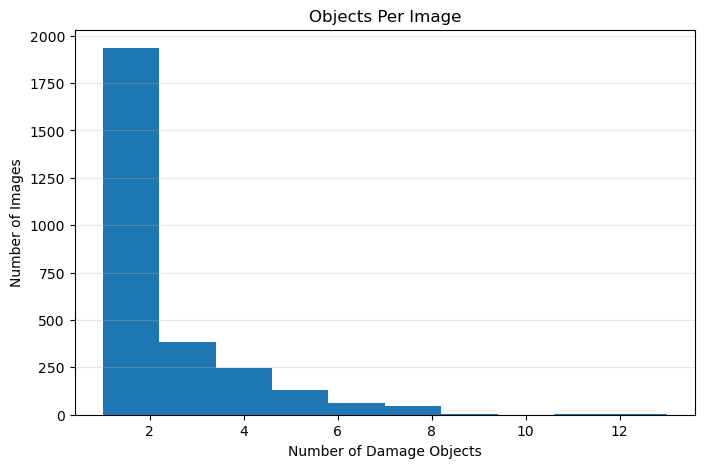

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(objects_df["Objects"], bins=10)
plt.title("Objects Per Image")
plt.xlabel("Number of Damage Objects")
plt.ylabel("Number of Images")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
# bounding box size analysis

box_areas = []

for label_file in os.listdir(TRAIN_LABELS):
    with open(os.path.join(TRAIN_LABELS, label_file)) as f:
        for line in f:
            _, _, _, w, h = map(float, line.split())
            box_areas.append(w * h)

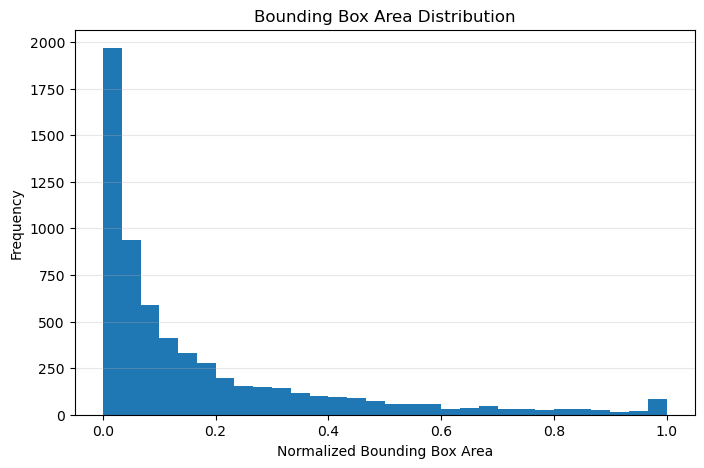

In [47]:
plt.figure(figsize=(8,5))
plt.hist(box_areas, bins=30)
plt.title("Bounding Box Area Distribution")
plt.xlabel("Normalized Bounding Box Area")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()